In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pyroomacoustics as pa
import wave
import scipy.signal as sp

from calc_steering_vector import calculate_steering_vector

In [7]:
def write_file_from_time_signal(data, save_path, sample_rate):
    data = data.astype(np.int16)
    save_file = wave.open(save_path, 'w')
    save_file.setnchannels(1)
    save_file.setsampwidth(2)
    save_file.setframerate(sample_rate)
    save_file.writeframes(data)
    save_file.close()

In [8]:
def save_spectrogram_img(data, save_path, sample_rate, fft_size, noverlap):
    # スペクトログラムをプロットする
    fig = plt.figure(figsize=(10, 4))
    # スペクトログラムを表示する
    spectrum, freqs, t, im = plt.specgram(data, NFFT=fft_size, noverlap=noverlap, Fs=sample_rate)
    # カラーバーを表示する
    fig.colorbar(im).set_label('Intensity [dB]')
    # x軸のラベル
    plt.xlabel("Time [sec]")
    # y軸のラベル
    plt.ylabel("Frequency [Hz]")
    # 音声ファイルを画像として保存
    plt.savefig(save_path)

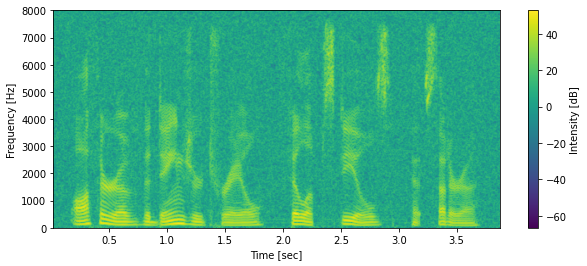

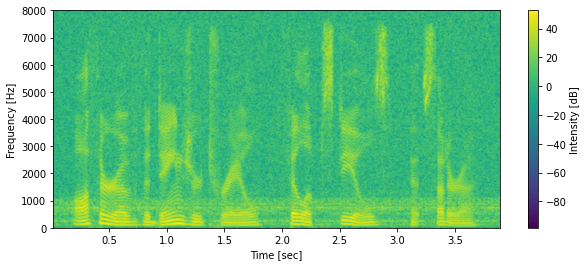

In [11]:
# 乱数の種を初期化
np.random.seed(0)
# 畳み込みに用いる波形
clean_wave_files = ["./CMU_ARCTIC/cmu_us_aew/wav/arctic_a0001.wav"]
n_sources = len(clean_wave_files)
# 音声波形の長さを調べる
n_samples = 0
# ファイルを読み込む
for clean_wave_file in clean_wave_files:
    wav = wave.open(clean_wave_file)
    if n_samples<wav.getnframes():
        n_samples=wav.getnframes()
    wav.close()
clean_data = np.zeros([n_sources, n_samples])

# ファイルを読み込む
s = 0
for clean_wave_file in clean_wave_files:
    wav = wave.open(clean_wave_file)
    data = wav.readframes(wav.getnframes())
    data = np.frombuffer(data, dtype=np.int16)
    data = data/np.iinfo(np.int16).max
    clean_data[s, :wav.getnframes()] = data
    wav.close()
    s = s+1

# シミュレーションのパラメータ
# サンプリングレート [Hz]
sample_rate = 16000
# フレームサイズ
N = 1024
# 周波数の数
Nk = N / 2 + 1
# 各ビンの周波数
freqs = np.arange(0, Nk, 1) * sample_rate / N
# 音声と雑音の比率 [dB]
SNR = 20.
# 生成した音が割れないようにするための振幅調整用パラメータ
amp_decay = 20
# 部屋の大きさ
room_dim = np.r_[10.0, 10.0, 10.0]
# マイクロホンアレイを置く部屋の場所
mic_array_loc = room_dim / 2 + np.random.randn(3) * 0.1
# マイクロホンアレイのマイクロホン配置（2個）
mic_alignments = np.array(
    [
        [-0.01, 0.0, 0.0],
        [0.01, 0.0, 0.0]
    ]
)
# # マイクロホンアレイのマイクロホン配置（32個）
# mic_alignments = np.array(
#         [[x, 0.0, 0.0] for x in np.arange(-0.31, 0.32, 0.02)]
# )

# マイクロホン数
n_channels = np.shape(mic_alignments)[0]
# get the microphone array
R  = mic_alignments.T + mic_array_loc[:, None]
"""R: (3D-coordinate(x,y,z)=3, num_microphones)"""
# 部屋を生成する
room = pa.ShoeBox(room_dim, fs=sample_rate, max_order=0)
# 用いるマイクロホンアレイの情報を設置する
room.add_microphone_array(pa.MicrophoneArray(R, fs=room.fs))
# 音源の場所
doas  = np.array(
    [[np.pi/2, 0]]
    )
# 音源とマイクロホンの距離
distance = 1.
source_locations = np.zeros((3, doas.shape[0]), dtype=doas.dtype)
"""source_locations: (xyz, num_sources)"""
source_locations[0,  :] = np.cos(doas[:, 1]) * np.sin(doas[:, 0]) 
source_locations[1,  :] = np.sin(doas[:, 1]) * np.sin(doas[:, 0])
source_locations[2,  :] = np.cos(doas[:, 0])
source_locations *= distance
source_locations += mic_array_loc[:, None] # マイクロホンアレイからの相対位置→絶対位置
# print("clean_data:", np.shape(clean_data))

# 各音源をシミュレーションに追加する
for s in range(n_sources):
    clean_data[s] /= np.std(clean_data[s])
    room.add_source(source_locations[:, s], signal=clean_data[s])

# シミュレーションを回す
room.simulate(snr=SNR)

# 畳み込んだ波形を取得する（チャンネル、サンプル）
multi_conv_data = room.mic_array.signals
"""multi_conv_data: (num_channels, num_samples)"""

# 畳み込んだ波形をファイルに書き込む
write_file_from_time_signal(multi_conv_data[0]*np.iinfo(np.int16).max/amp_decay, "./wav/mix_in.wav", sample_rate)
save_spectrogram_path = "./spectrogram/mix_in.png"
save_spectrogram_img(multi_conv_data[0]*np.iinfo(np.int16).max/amp_decay, save_spectrogram_path, sample_rate, fft_size=512, noverlap=512/16*15)

# Near仮定に基づくステアリングベクトルを計算: steering_vectors(Nk × Ns × M)
near_steering_vectors = calculate_steering_vector(R, source_locations, freqs,  is_use_far=False)
"""near_steering_vectors: (freq_bins, num_sources, num_microphones)"""
# 短時間フーリエ変換
f, t, stft_data = sp.stft(multi_conv_data, fs=sample_rate, window="hann", nperseg=N)
"""f: (freq_bins,), t: (1,), stft_data: (num_microphones, freq_bins, time_frames)"""

# 最尤ビームフォーマ
# 雑音だけの区間のサンプル数を設定
n_noise_only = 4000
# 雑音だけの区間のフレーム数
n_noise_only_frame = np.sum(t < (n_noise_only / sample_rate))
# 共分散行列を計算する
Rcov =  np.einsum("mkt,nkt->kmn", stft_data[..., :n_noise_only_frame], np.conjugate(stft_data[..., :n_noise_only_frame]))
"""Rcov: (freq_bins, num_microphones, num_microphones)"""
# 共分散行列の逆行列を計算する
Rcov_inverse = np.linalg.pinv(Rcov)
"""Rcov_inverse: (freq_bins, num_microphones, num_microphones)"""
# 分離フィルタを計算する
Rcov_inverse_a = np.einsum("kmn,kn->km", Rcov_inverse, near_steering_vectors[:, 0, :]) # 分子
"""Rcov_inverse_a: (freq_bins, num_microphones)"""
a_H_Rcov_inverse_a = np.einsum("kn,kn->k", np.conjugate(near_steering_vectors[:, 0, :]), Rcov_inverse_a) # 分母
"""a_H_Rcov_inverse_a: (freq_bins,)"""
w_mvdr = Rcov_inverse_a / np.maximum(a_H_Rcov_inverse_a, 1.e-18)[:, None]
"""w_mvdr: (freq_bins, num_microphones)"""
# 分離フィルタを掛ける
s_hat = np.einsum("km,mkt->kt", np.conjugate(w_mvdr), stft_data)
"""s_hat: (freq_bins, time_frames)"""
# ステアリングベクトルを掛ける（マイクロホン入力信号中の目的音成分を推定）
c_hat = np.einsum("kt,km->mkt", s_hat, near_steering_vectors[:, 0, :])
"""c_hat: (num_microphones, freq_bins, time_frames)"""
# 時間領域の波形に戻す
t, ml_out = sp.istft(c_hat[0], fs=sample_rate, window="hann", nperseg=N)
"""mvdr_out: (1, num_samples)"""
# 大きさを調整する
ml_out = ml_out * np.iinfo(np.int16).max / amp_decay

# ファイルを書き込む
write_file_from_time_signal(ml_out, "./wav/ml_out.wav", sample_rate)
save_spectrogram_path = "./spectrogram/ml_out.png"
save_spectrogram_img(ml_out, save_spectrogram_path, sample_rate, fft_size=512, noverlap=512/16*15)